In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("balanced_clickstream_dataset.csv")

In [6]:
df.duplicated().sum()

0

In [7]:
df = df.drop_duplicates()

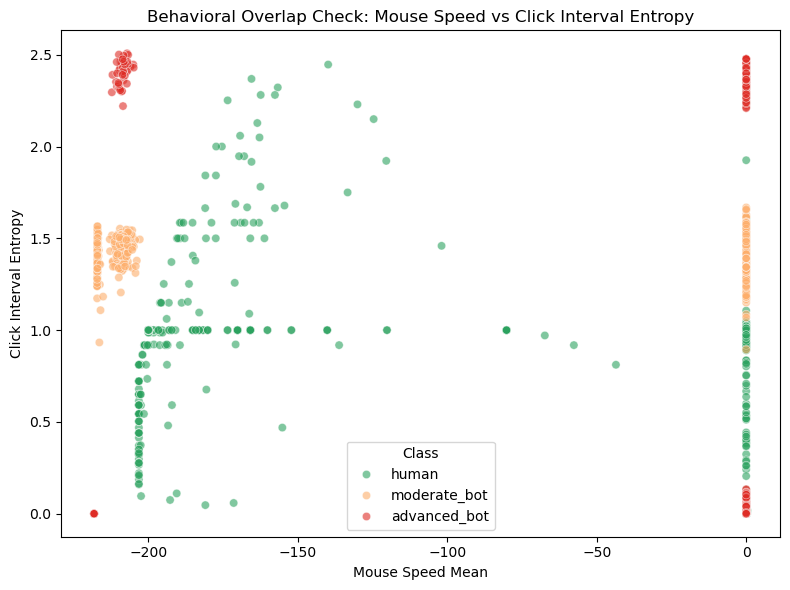

In [10]:
# Map label numbers to readable names (if needed)
label_map = {
    0: "human",
    1: "moderate_bot",
    2: "advanced_bot"
}

df["label_name"] = df["label"].map(label_map)

# Plot behavioural overlap
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="mouse_speed_mean",
    y="click_interval_entropy",
    hue="label_name",
    palette=["#2ca25f", "#fdae6b", "#de2d26"],
    alpha=0.6
)

plt.title("Behavioral Overlap Check: Mouse Speed vs Click Interval Entropy")
plt.xlabel("Mouse Speed Mean")
plt.ylabel("Click Interval Entropy")
plt.legend(title="Class")

plt.tight_layout()
plt.show()

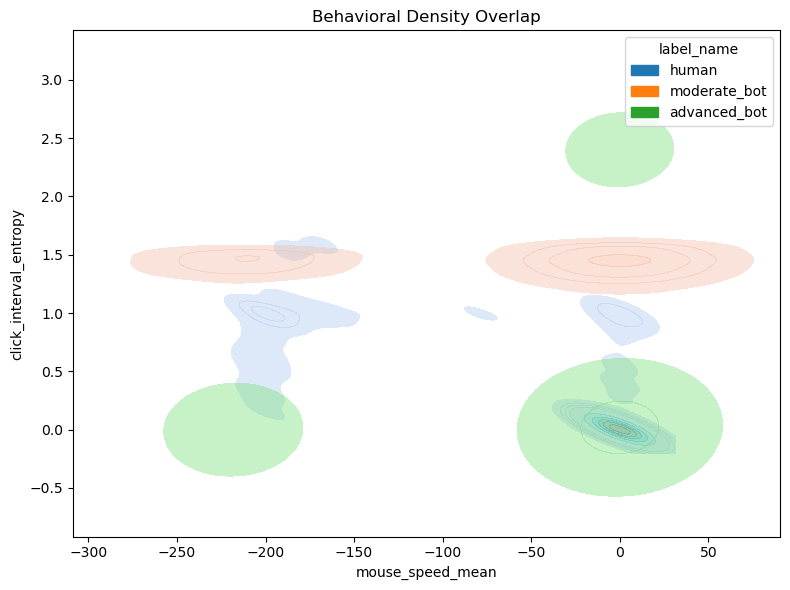

In [11]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df,
    x="mouse_speed_mean",
    y="click_interval_entropy",
    hue="label_name",
    fill=True,
    alpha=0.4
)

plt.title("Behavioral Density Overlap")
plt.tight_layout()
plt.show()

In [12]:
df.groupby("label")[[
    "mouse_speed_mean",
    "click_interval_entropy",
    "requests_per_minute"
]].describe()

mouse_speed_mean                                                     \
                 count       mean        std         min         25%  50%   
label                                                                       
0               5013.0 -10.103739  42.502611 -203.181818    0.000000  0.0   
1               1000.0 -55.653178  93.236101 -217.155804 -205.800260  0.0   
2               1000.0 -56.903339  95.323991 -218.181818 -207.879197  0.0   

                     click_interval_entropy            ...            \
       75%       max                  count      mean  ...       75%   
label                                                  ...             
0      0.0  0.385273                 5013.0  0.077302  ...  0.000000   
1      0.0  0.000000                 1000.0  1.430662  ...  1.496494   
2      0.0  0.000000                 1000.0  0.506139  ...  0.069367   

                requests_per_minute                                            \
            max               count       mean        std        min      25%   
label                                                                           
0      2.446439              5013.0  -1.908626  14.962219 -59.932203   0.0000   
1      1.668191              1000.0 -13.625475  22.827527 -54.712500 -50.5125   
2      2.507561              1000.0  12.233452  35.090891 -59.741019   0.0000   

                              
       50%        75%    max  
label                         
0      0.0   0.000000  360.0  
1      0.0   0.000000    0.0  
2      0.0  11.528097  300.0  

[3 rows x 24 columns]

In [14]:
df[df["mouse_speed_mean"] == 0].groupby("label").size()

label
0    4011
1     737
2     737
dtype: int64